# CRISPR Gene Editing Analysis Pipeline — Results Report

**Author:** Priya D  
**Date:** April 2026  
**Project:** Automated pipeline for analyzing CRISPR gene editing outcomes from amplicon sequencing

## Overview
This notebook presents the results of analyzing three CRISPR gene editing experiments using CRISPResso2:
1. **Cas9 NHEJ** — Standard Cas9 nuclease creating insertions/deletions
2. **Base Editor (EMX1)** — Adenine base editor making precise A→G changes
3. **Allele-Specific (Rho)** — Cas9 targeting only the P23H mutant allele

The pipeline was automated using Snakemake and can be reproduced with a single command.

In [1]:
## 1. Loading Libraries and Data

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import os

# Set consistent styling
mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 12,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 150,
})

COLORS = {
    'primary': '#1B4F72',
    'secondary': '#2E86C1',
    'tertiary': '#85C1E9',
    'accent': '#D4E6F1',
}

CRISPRESSO_DIR = "../results/crispresso"

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 2. Editing Efficiency Across Experiments
Lets compare how efficiently each editing approach modified the target DNA.

In [5]:
# Load quantification data from all 3 experiments
experiments = {
    "Cas9 (NHEJ)": "CRISPResso_on_nhej",
    "Base Editor (EMX1)": "CRISPResso_on_base_editor",
    "Allele-Specific (Rho)": "CRISPResso_on_allele_specific"
}

all_data = []
for label, folder in experiments.items():
    filepath = os.path.join(CRISPRESSO_DIR, folder, "CRISPResso_quantification_of_editing_frequency.txt")
    df = pd.read_csv(filepath, sep="\t")
    df["Experiment"] = label
    all_data.append(df)

combined = pd.concat(all_data, ignore_index=True)
print(combined[["Experiment", "Amplicon", "Reads_aligned", "Unmodified%", "Modified%"]].to_string(index=False))

           Experiment  Amplicon  Reads_aligned  Unmodified%  Modified%
          Cas9 (NHEJ) Reference          24478    23.388349  76.611651
   Base Editor (EMX1) Reference          24970    71.021225  28.978775
Allele-Specific (Rho)      P23H          11303    44.678404  55.321596
Allele-Specific (Rho)        WT          12751    77.578229  22.421771


### Key Findings:
- **Cas9 NHEJ** achieved the highest editing rate (76.6%), as expected for a nuclease that creates double-strand breaks
- **Base Editor** showed 29.0% modification — lower because base editors make subtle single-base changes rather than large indels
- **Allele-Specific** editing showed clear discrimination: the P23H mutant allele was edited at 55.3% vs only 22.4% for wild-type — a 2.5x preference for the target allele

## 3. Visualizing Editing Efficiency

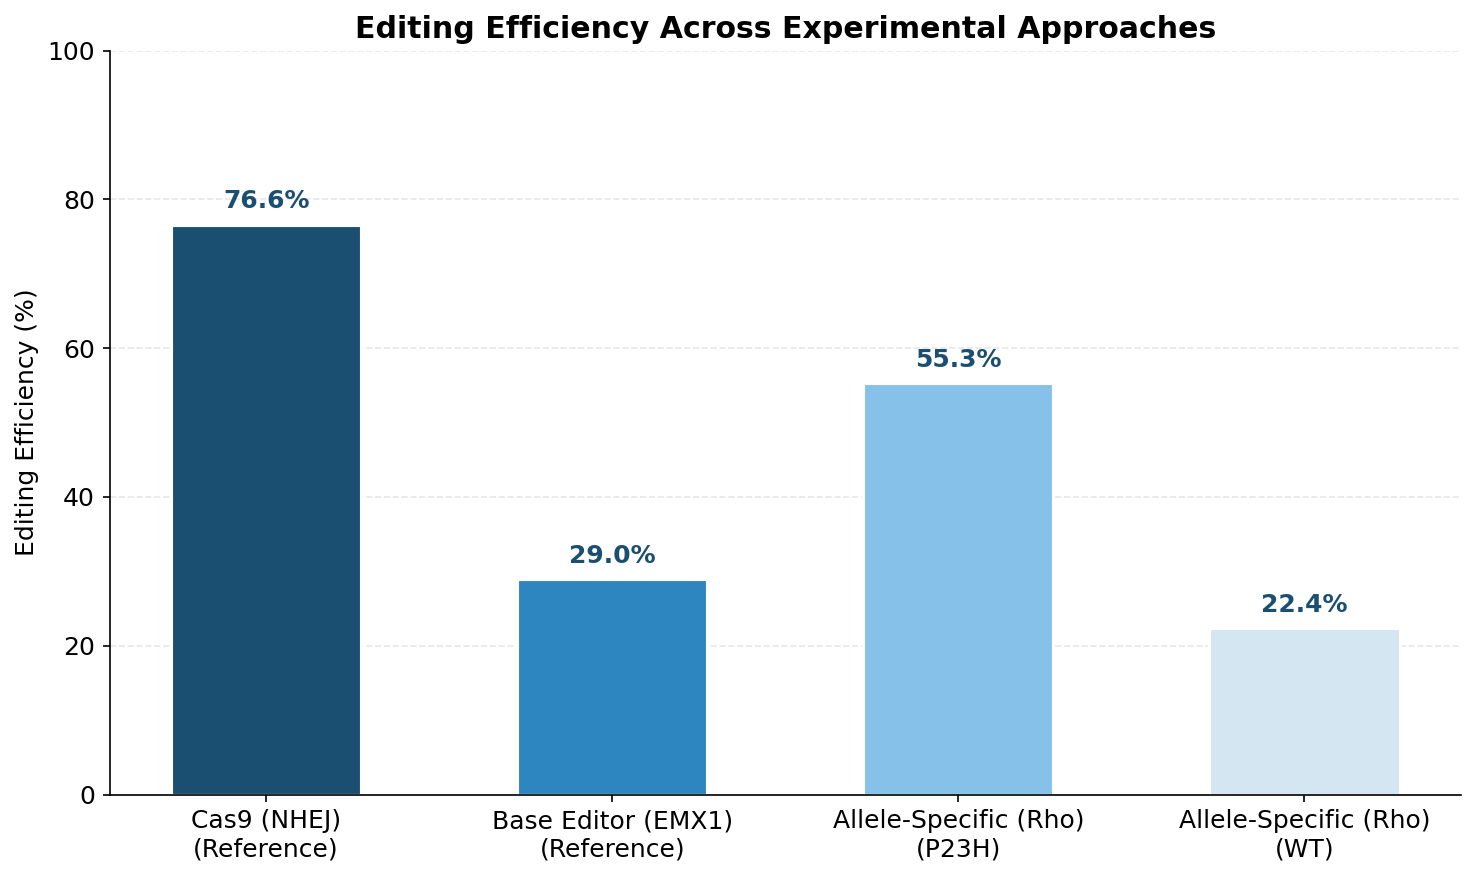

In [6]:
labels = []
modified_pcts = []
bar_colors = [COLORS['primary'], COLORS['secondary'], COLORS['tertiary'], COLORS['accent']]

for _, row in combined.iterrows():
    labels.append(f"{row['Experiment']}\n({row['Amplicon']})")
    modified_pcts.append(row["Modified%"])

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(range(len(labels)), modified_pcts, color=bar_colors[:len(labels)], 
              edgecolor='white', width=0.55, linewidth=1.5)

for bar, val in zip(bars, modified_pcts):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1.5,
            f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=12, color=COLORS['primary'])

ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.set_ylabel("Editing Efficiency (%)")
ax.set_title("Editing Efficiency Across Experimental Approaches", fontweight="bold")
ax.set_ylim(0, 100)
ax.yaxis.grid(True, alpha=0.3, linestyle='--')
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

## 4. Indel Size Distribution (Cas9 NHEJ)
Cas9 creates double-strand breaks that are repaired by NHEJ, resulting in insertions and deletions of varying sizes. The distribution of indel sizes reveals the "fingerprint" of Cas9 editing.

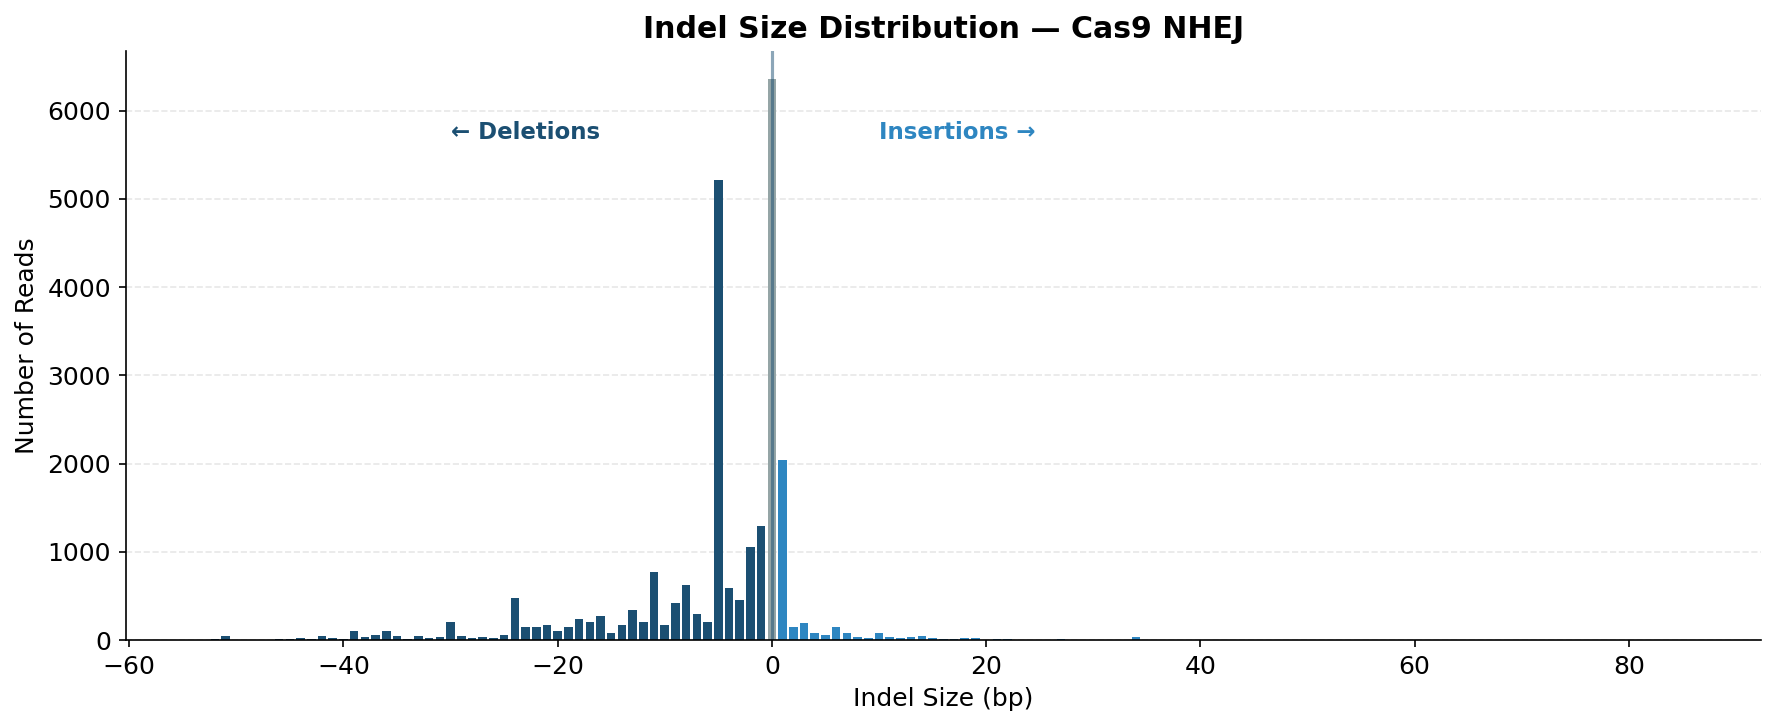

In [7]:
indel_file = os.path.join(CRISPRESSO_DIR, "CRISPResso_on_nhej", "Indel_histogram.txt")
df_indel = pd.read_csv(indel_file, sep="\t")

sizes = df_indel.iloc[:, 0]
counts = df_indel.iloc[:, 1]
colors = [COLORS['primary'] if s < 0 else COLORS['secondary'] if s > 0 else '#95a5a6' for s in sizes]

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(sizes, counts, color=colors, edgecolor='none', width=0.8)
ax.axvline(x=0, color=COLORS['primary'], linestyle='-', alpha=0.5, linewidth=1.5)
ax.set_xlabel("Indel Size (bp)")
ax.set_ylabel("Number of Reads")
ax.set_title("Indel Size Distribution — Cas9 NHEJ", fontweight="bold")
ax.yaxis.grid(True, alpha=0.3, linestyle='--')
ax.set_axisbelow(True)
ax.annotate('← Deletions', xy=(-30, ax.get_ylim()[1]*0.85), fontsize=11, color=COLORS['primary'], fontweight='bold')
ax.annotate('Insertions →', xy=(10, ax.get_ylim()[1]*0.85), fontsize=11, color=COLORS['secondary'], fontweight='bold')
plt.tight_layout()
plt.show()

### Observations:
- **Small deletions (1-10 bp)** are the most common editing outcome, which is typical for Cas9 NHEJ repair
- **Small insertions (1-5 bp)** are the second most common outcome
- **Large deletions** (up to -50 bp) occur but at lower frequency
- This indel profile is consistent with published Cas9 editing signatures

## 5. Allele Discrimination Analysis
A key requirement for therapeutic gene editing is the ability to edit only the disease-causing allele without modifying the healthy copy. Here we analyze how well the guide RNA discriminates between the P23H mutant and wild-type alleles of the Rho gene.

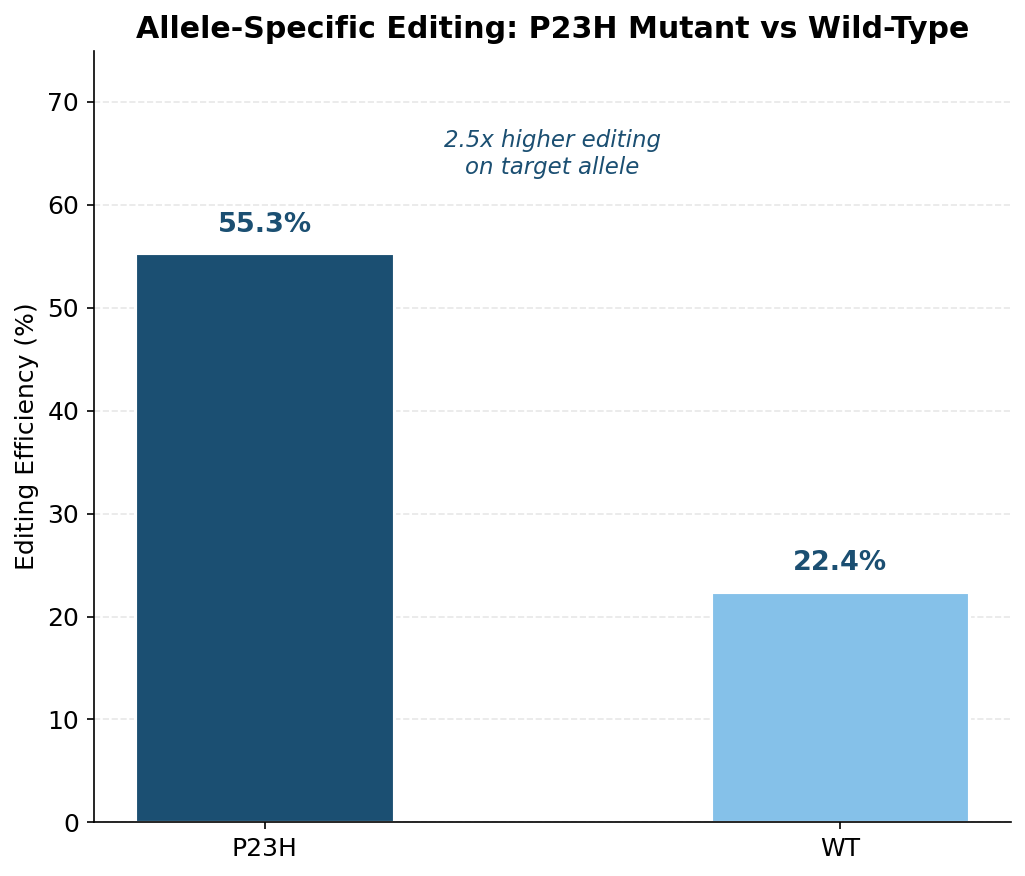

In [8]:
allele_file = os.path.join(CRISPRESSO_DIR, "CRISPResso_on_allele_specific", 
                            "CRISPResso_quantification_of_editing_frequency.txt")
df_allele = pd.read_csv(allele_file, sep="\t")

fig, ax = plt.subplots(figsize=(7, 6))
bars = ax.bar(df_allele["Amplicon"], df_allele["Modified%"], 
              color=[COLORS['primary'], COLORS['tertiary']], edgecolor='white', width=0.45, linewidth=1.5)

for bar, val in zip(bars, df_allele["Modified%"]):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1.5,
            f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=13, color=COLORS['primary'])

ax.set_ylabel("Editing Efficiency (%)")
ax.set_title("Allele-Specific Editing: P23H Mutant vs Wild-Type", fontweight="bold")
ax.set_ylim(0, 75)
ax.yaxis.grid(True, alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

fold = df_allele[df_allele["Amplicon"]=="P23H"]["Modified%"].values[0] / df_allele[df_allele["Amplicon"]=="WT"]["Modified%"].values[0]
ax.annotate(f'{fold:.1f}x higher editing\non target allele', xy=(0.5, 63), fontsize=11, ha='center',
            color=COLORS['primary'], fontstyle='italic')
plt.tight_layout()
plt.show()

### Therapeutic Implications:
- The guide RNA shows **2.5-fold preference** for the P23H mutant allele over wild-type
- This level of discrimination is important for therapeutic applications where you want to correct a mutation without disrupting the healthy copy
- Further optimization of guide RNA design or use of high-fidelity Cas9 variants could improve this discrimination ratio

## 6. Conclusions

This analysis demonstrates a complete, automated pipeline for evaluating CRISPR gene editing outcomes from amplicon sequencing data. Key results:

1. **Cas9 nuclease** achieved 76.6% editing efficiency with a characteristic indel profile dominated by small deletions
2. **Base editing** at the EMX1 locus showed 29.0% modification rate with precise substitution patterns
3. **Allele-specific editing** demonstrated 2.5-fold discrimination between mutant and wild-type alleles

### Pipeline Features:
- Automated with Snakemake — full analysis runs with a single command
- Reproducible — conda environment and version-controlled code
- Extensible — new samples can be added by editing the config file
- Relevant to therapeutic gene editing safety assessment, particularly for LNP-delivered editing approaches

### Tools Used:
FastQC, MultiQC, CRISPResso2, Snakemake, Python (pandas, matplotlib)